# Search Ranking Model — Exploratory Data Analysis

This notebook walks through:
1. Dataset overview & quality checks
2. Relevance label distribution
3. Feature distributions & outliers
4. Feature–relevance correlations
5. Query-level statistics
6. Feature collinearity heatmap
7. BM25 vs relevance deep-dive

In [1]:
import sys
sys.path.insert(0, '..')  # make src importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120

DATA_PATH = '../data/raw/queries_docs.csv'
FEATURE_COLS = [
    'bm25_score', 'tfidf_cosine', 'query_term_coverage',
    'title_match_score', 'body_match_score',
    'doc_length', 'doc_pagerank', 'doc_freshness_days', 'avg_click_rate',
    'query_length', 'query_idf_sum', 'is_navigational',
]
LABEL_COL = 'relevance'
GROUP_COL = 'qid'

## 1. Load & overview

In [2]:
# Generate sample data if not present
if not Path(DATA_PATH).exists():
    from src.data.generate_sample_data import generate_dataset
    generate_dataset(DATA_PATH)

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Queries: {df[GROUP_COL].nunique()}')
print(f'Docs per query (mean): {df.groupby(GROUP_COL).size().mean():.1f}')
df.head()

Shape: (200, 16)
Queries: 10
Docs per query (mean): 20.0


,qid,doc_id,query,relevance,bm25_score,tfidf_cosine,query_term_coverage,title_match_score,body_match_score,doc_length,doc_pagerank,doc_freshness_days,avg_click_rate,query_length,query_idf_sum,is_navigational
0,q0000,d0000_0000,machine learning tutorial,3,12.195859,0.739564,1.000000,0.920939,0.996640,244,0.335218,217,0.406603,3,20.479121,0
1,q0000,d0000_0001,machine learning tutorial,3,16.562830,1.000000,0.856168,1.000000,0.990015,444,0.411788,367,0.384547,3,20.479121,0
2,q0000,d0000_0002,machine learning tutorial,3,22.129237,1.000000,1.000000,1.000000,1.000000,378,0.654245,47,0.461598,3,20.479121,0
3,q0000,d0000_0003,machine learning tutorial,0,0.000000,0.000000,0.097589,0.185814,0.108631,300,0.677169,224,0.021869,3,20.479121,0
4,q0000,d0000_0004,machine learning tutorial,2,16.048988,0.680182,0.710035,0.824489,0.375236,404,0.342020,79,0.239152,3,20.479121,0


In [3]:
# Data quality: missing values
missing = df[FEATURE_COLS + [LABEL_COL]].isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.any() else '  None — dataset is clean ✓')

# Basic stats
df[FEATURE_COLS + [LABEL_COL]].describe().round(3)

Missing values:
  None — dataset is clean ✓


,bm25_score,tfidf_cosine,query_term_coverage,title_match_score,body_match_score,doc_length,doc_pagerank,doc_freshness_days,avg_click_rate,query_length,query_idf_sum,is_navigational,relevance
count,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000
mean,7.840,0.393,0.384,0.397,0.389,492.885,0.618,191.730,0.167,3.300,13.721,0.300,1.145
std,7.063,0.318,0.312,0.324,0.314,276.190,0.481,173.502,0.138,0.642,4.948,0.459,0.926
min,0.000,0.000,0.000,0.000,0.000,100.000,0.009,1.000,0.000,3.000,6.936,0.000,0.000
25%,1.154,0.127,0.114,0.107,0.112,285.500,0.284,70.250,0.037,3.000,7.903,0.000,0.750
50%,6.413,0.352,0.337,0.372,0.355,463.500,0.528,137.000,0.155,3.000,14.453,0.000,1.000
75%,12.821,0.576,0.622,0.658,0.596,671.500,0.788,270.250,0.248,3.000,16.104,1.000,2.000
max,26.590,1.000,1.000,1.000,1.000,1343.000,3.119,828.000,0.613,5.000,21.682,1.000,3.000


## 2. Relevance label distribution

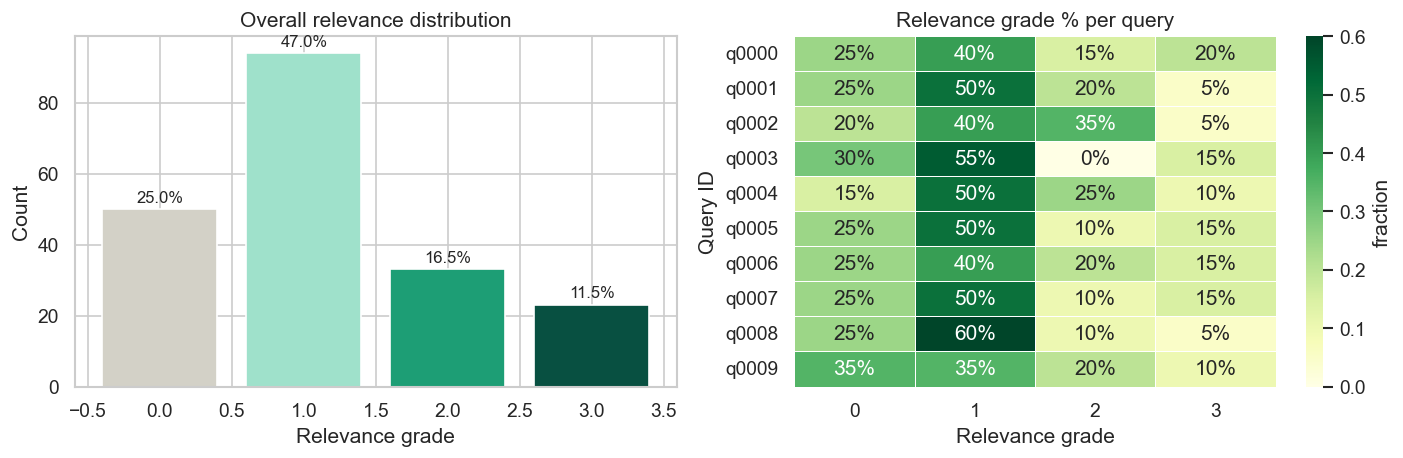

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overall distribution
counts = df[LABEL_COL].value_counts().sort_index()
axes[0].bar(counts.index, counts.values, color=['#d3d1c7','#9FE1CB','#1D9E75','#085041'])
axes[0].set_xlabel('Relevance grade')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall relevance distribution')
for i, (grade, cnt) in enumerate(counts.items()):
    axes[0].text(grade, cnt + 2, f'{cnt/len(df)*100:.1f}%', ha='center', fontsize=10)

# Per-query distribution heatmap
qrel = df.groupby([GROUP_COL, LABEL_COL]).size().unstack(fill_value=0)
qrel_pct = qrel.div(qrel.sum(axis=1), axis=0)
sns.heatmap(qrel_pct, ax=axes[1], cmap='YlGn', annot=True, fmt='.0%',
            linewidths=0.5, cbar_kws={'label': 'fraction'})
axes[1].set_title('Relevance grade % per query')
axes[1].set_xlabel('Relevance grade')
axes[1].set_ylabel('Query ID')

plt.tight_layout()
plt.savefig('../outputs/eda_relevance_dist.png', bbox_inches='tight')
plt.show()

## 3. Feature distributions

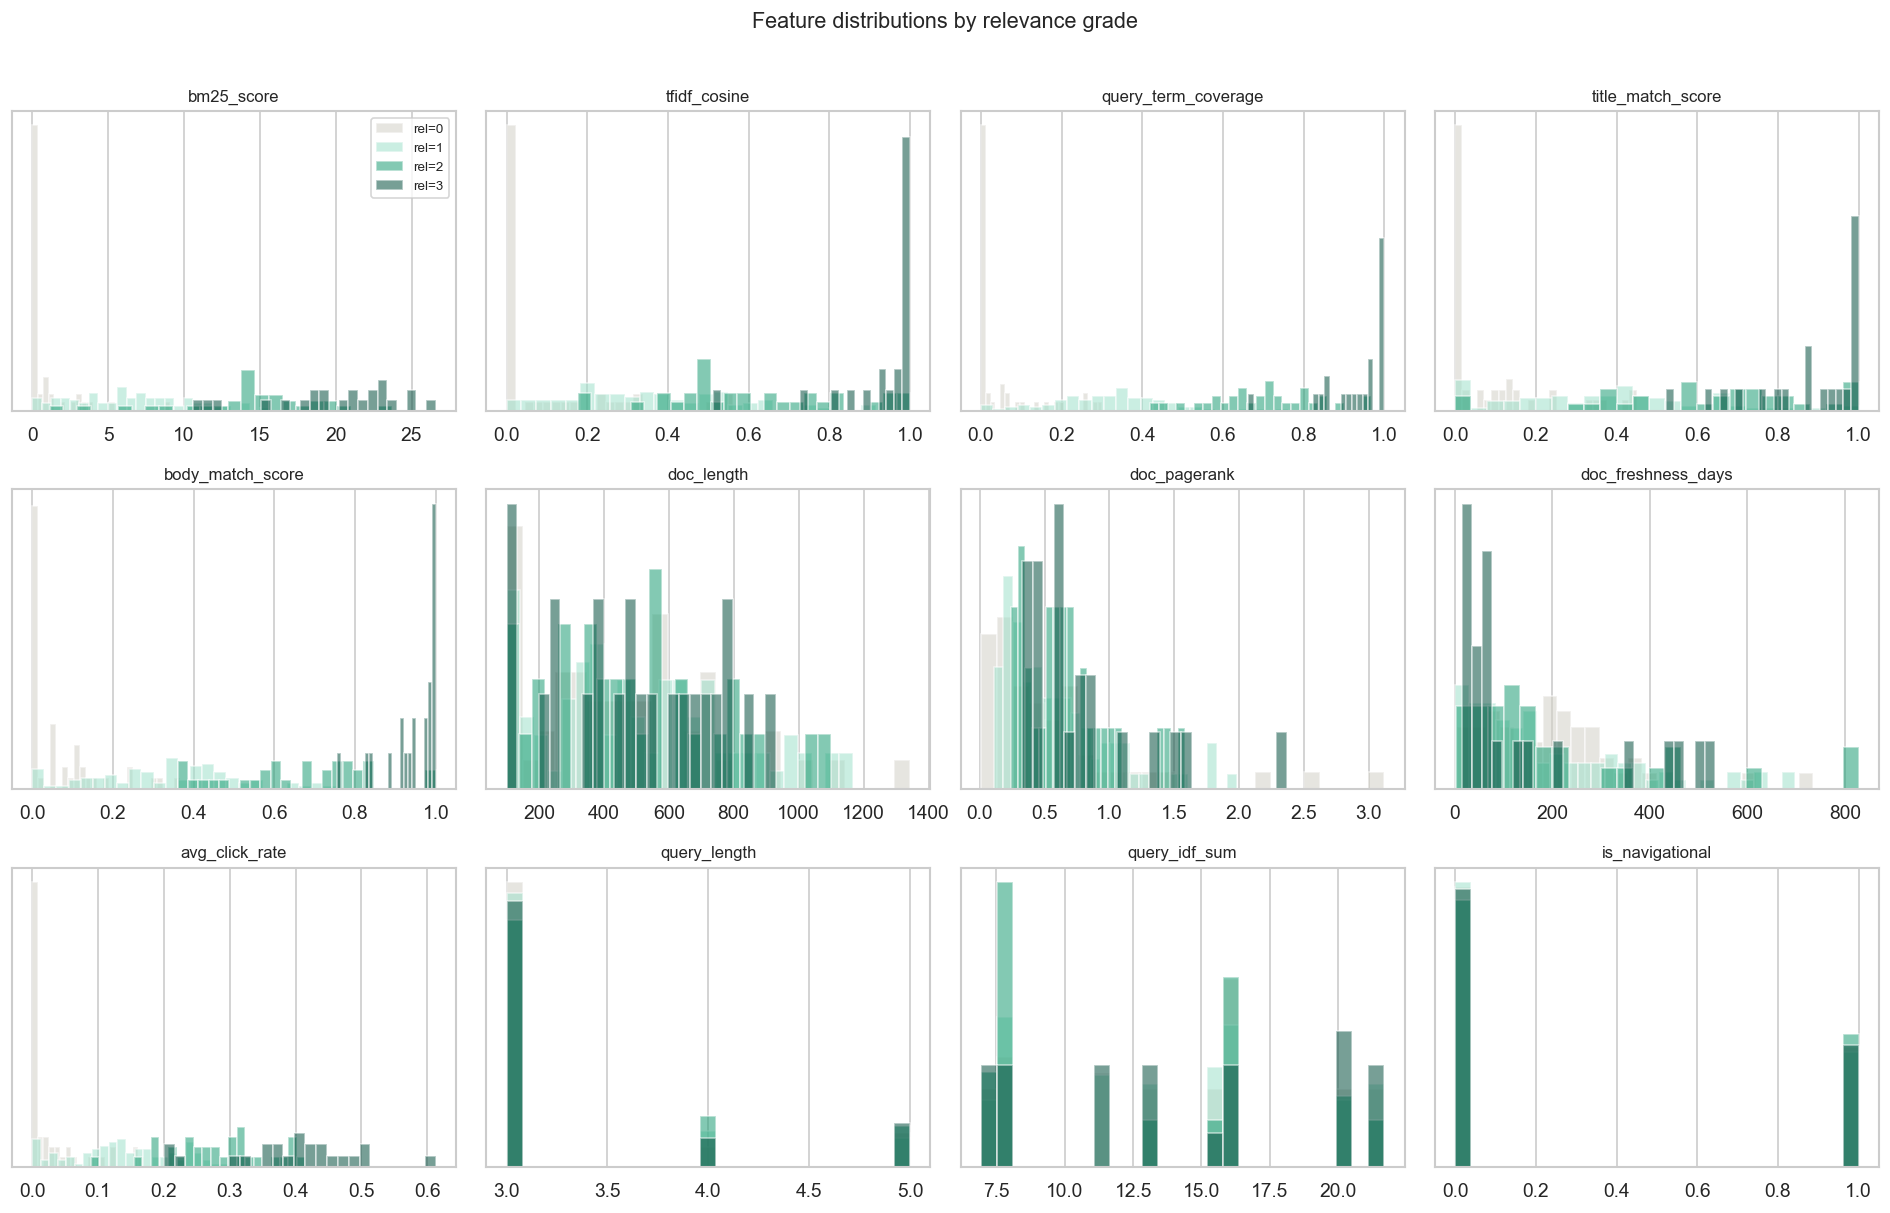

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

palette = {0: '#d3d1c7', 1: '#9FE1CB', 2: '#1D9E75', 3: '#085041'}

for i, feat in enumerate(FEATURE_COLS):
    ax = axes[i]
    for grade in sorted(df[LABEL_COL].unique()):
        subset = df[df[LABEL_COL] == grade][feat]
        ax.hist(subset, bins=25, alpha=0.55, label=f'rel={grade}',
                color=palette[grade], density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_yticks([])
    if i == 0:
        ax.legend(fontsize=8, loc='upper right')

# Hide unused axes
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature distributions by relevance grade', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/eda_feature_dists.png', bbox_inches='tight')
plt.show()

## 4. Feature–relevance correlation

C:\Users\Acer\AppData\Local\Temp\ipykernel_17940\1284177135.py:23: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Acer\AppData\Local\Temp\ipykernel_17940\1284177135.py:24: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('../outputs/eda_correlations.png', bbox_inches='tight')
d:\mcp-server\search_ranking_model\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


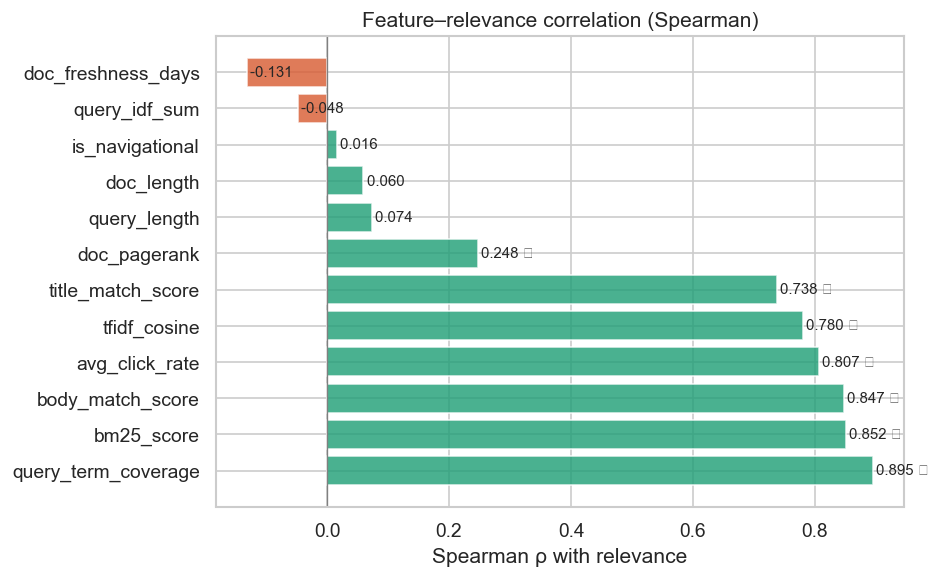

                     spearman_r  p_value  significant
query_term_coverage      0.8950   0.0000         True
bm25_score               0.8516   0.0000         True
body_match_score         0.8470   0.0000         True
avg_click_rate           0.8068   0.0000         True
tfidf_cosine             0.7799   0.0000         True
title_match_score        0.7376   0.0000         True
doc_pagerank             0.2481   0.0004         True
query_length             0.0739   0.2980        False
doc_length               0.0596   0.4015        False
is_navigational          0.0160   0.8225        False
query_idf_sum           -0.0481   0.4989        False
doc_freshness_days      -0.1314   0.0637        False


In [6]:
from scipy.stats import spearmanr

correlations = {}
for feat in FEATURE_COLS:
    r, p = spearmanr(df[feat], df[LABEL_COL])
    correlations[feat] = {'spearman_r': r, 'p_value': p}

corr_df = pd.DataFrame(correlations).T.sort_values('spearman_r', ascending=False)
corr_df['significant'] = corr_df['p_value'] < 0.05

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#1D9E75' if r > 0 else '#D85A30' for r in corr_df['spearman_r']]
bars = ax.barh(corr_df.index, corr_df['spearman_r'], color=colors, alpha=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel("Spearman ρ with relevance")
ax.set_title("Feature–relevance correlation (Spearman)")

for bar, (_, row) in zip(bars, corr_df.iterrows()):
    sig = '✓' if row['significant'] else ''
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{row["spearman_r"]:.3f} {sig}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/eda_correlations.png', bbox_inches='tight')
plt.show()
print(corr_df.round(4))

## 5. Query-level statistics

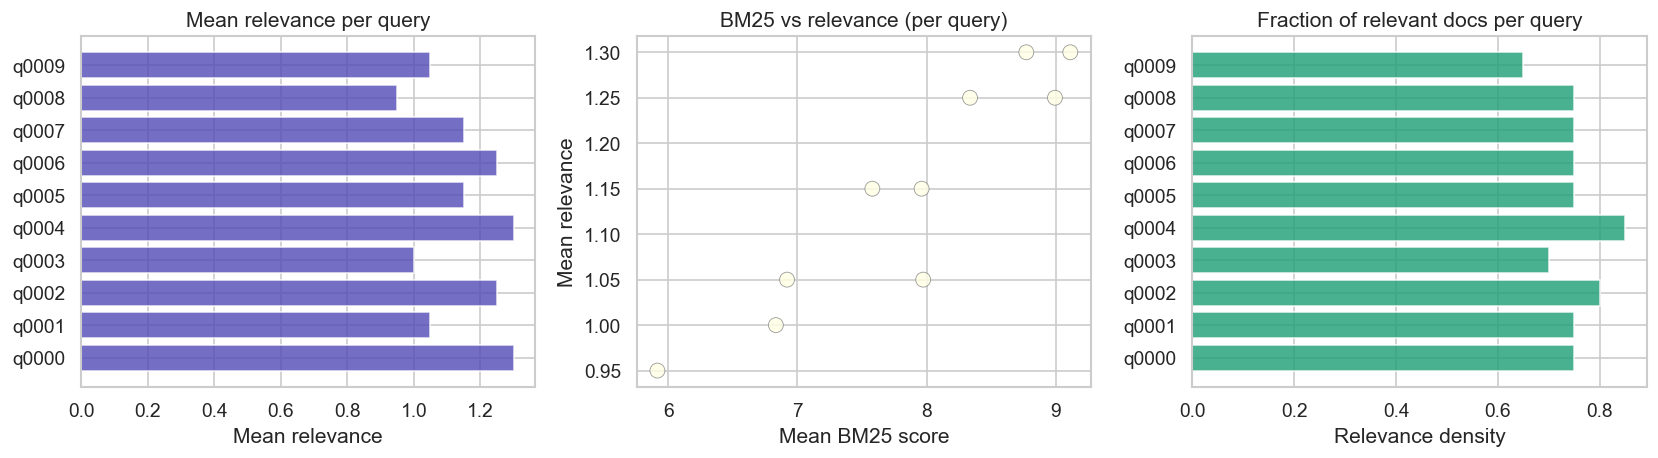

,qid,n_docs,mean_relevance,n_relevant,n_highly_relevant,max_bm25,mean_bm25,relevance_density
0,q0000,20,1.30,15,4,22.950062,8.771754,0.75
1,q0001,20,1.05,15,1,15.253907,6.919308,0.75
2,q0002,20,1.25,16,1,23.724028,8.336279,0.80
3,q0003,20,1.00,14,3,23.267103,6.832789,0.70
4,q0004,20,1.30,17,2,26.589576,9.112401,0.85
5,q0005,20,1.15,15,3,19.340249,7.579729,0.75
6,q0006,20,1.25,15,3,24.730123,8.993722,0.75
7,q0007,20,1.15,15,3,24.758488,7.961165,0.75
8,q0008,20,0.95,15,1,20.381756,5.915779,0.75
9,q0009,20,1.05,13,2,21.091450,7.973445,0.65


In [7]:
query_stats = df.groupby(GROUP_COL).agg(
    n_docs=('doc_id', 'count'),
    mean_relevance=(LABEL_COL, 'mean'),
    n_relevant=(LABEL_COL, lambda x: (x >= 1).sum()),
    n_highly_relevant=(LABEL_COL, lambda x: (x >= 3).sum()),
    max_bm25=('bm25_score', 'max'),
    mean_bm25=('bm25_score', 'mean'),
).reset_index()

query_stats['relevance_density'] = query_stats['n_relevant'] / query_stats['n_docs']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].barh(query_stats[GROUP_COL], query_stats['mean_relevance'], color='#534AB7', alpha=0.8)
axes[0].set_title('Mean relevance per query')
axes[0].set_xlabel('Mean relevance')

axes[1].scatter(query_stats['mean_bm25'], query_stats['mean_relevance'],
                c=query_stats['n_docs'], cmap='YlGn', s=80, alpha=0.8, edgecolors='gray', linewidth=0.5)
axes[1].set_xlabel('Mean BM25 score')
axes[1].set_ylabel('Mean relevance')
axes[1].set_title('BM25 vs relevance (per query)')

axes[2].barh(query_stats[GROUP_COL], query_stats['relevance_density'],
             color='#1D9E75', alpha=0.8)
axes[2].set_title('Fraction of relevant docs per query')
axes[2].set_xlabel('Relevance density')

plt.tight_layout()
plt.savefig('../outputs/eda_query_stats.png', bbox_inches='tight')
plt.show()
query_stats

## 6. Feature collinearity heatmap

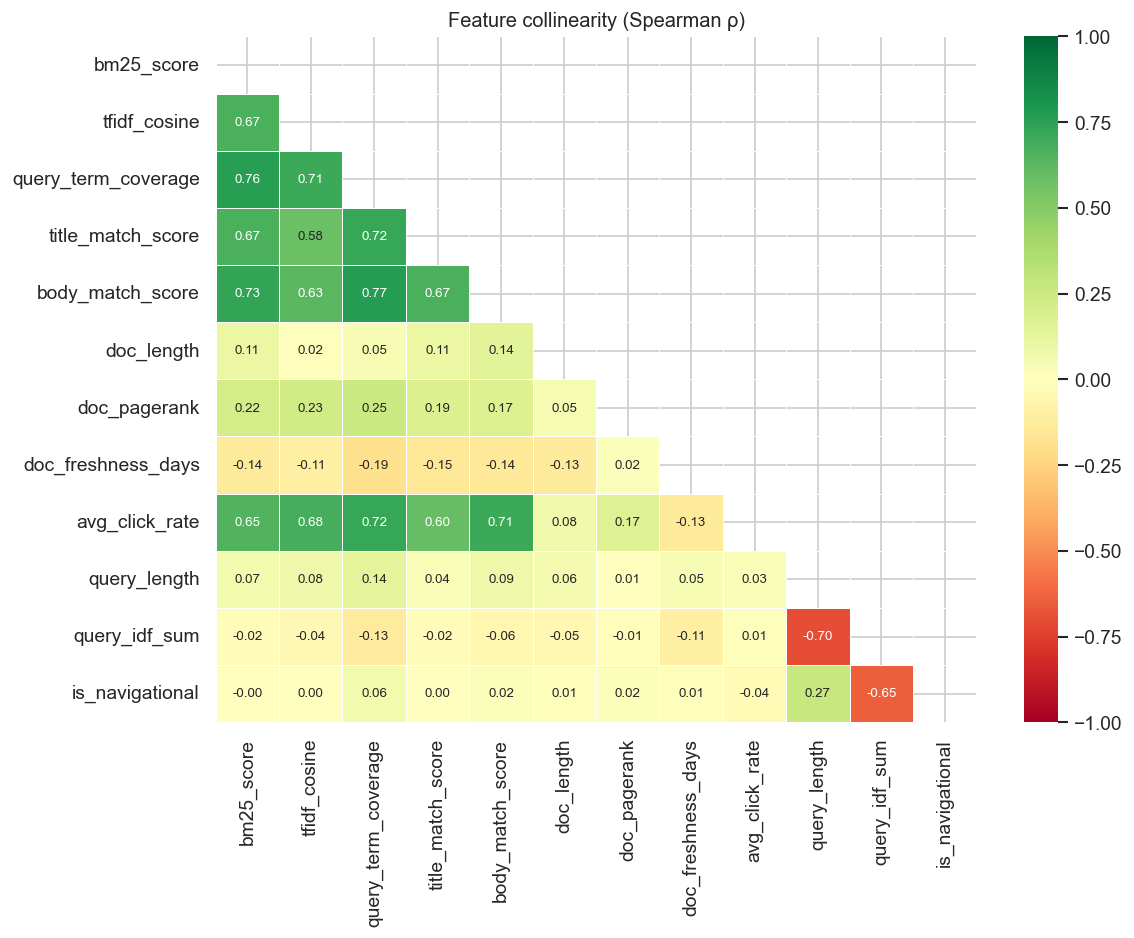

Highly correlated pairs (|ρ| > 0.7):
  bm25_score ↔ query_term_coverage: ρ=0.761
  bm25_score ↔ body_match_score: ρ=0.732
  tfidf_cosine ↔ query_term_coverage: ρ=0.707
  query_term_coverage ↔ title_match_score: ρ=0.722
  query_term_coverage ↔ body_match_score: ρ=0.769
  query_term_coverage ↔ avg_click_rate: ρ=0.722
  body_match_score ↔ avg_click_rate: ρ=0.709
  query_length ↔ query_idf_sum: ρ=-0.701


In [8]:
corr_matrix = df[FEATURE_COLS].corr(method='spearman')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdYlGn', center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    annot_kws={'size': 8}, ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Feature collinearity (Spearman ρ)', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/eda_collinearity.png', bbox_inches='tight')
plt.show()

# Flag highly correlated pairs
high_corr = []
for i, f1 in enumerate(FEATURE_COLS):
    for j, f2 in enumerate(FEATURE_COLS):
        if i < j:
            r = corr_matrix.loc[f1, f2]
            if abs(r) > 0.7:
                high_corr.append((f1, f2, round(r, 3)))

if high_corr:
    print('Highly correlated pairs (|ρ| > 0.7):')
    for a, b, r in high_corr:
        print(f'  {a} ↔ {b}: ρ={r}')
else:
    print('No highly correlated feature pairs found.')

## 7. BM25 score vs relevance — deep-dive

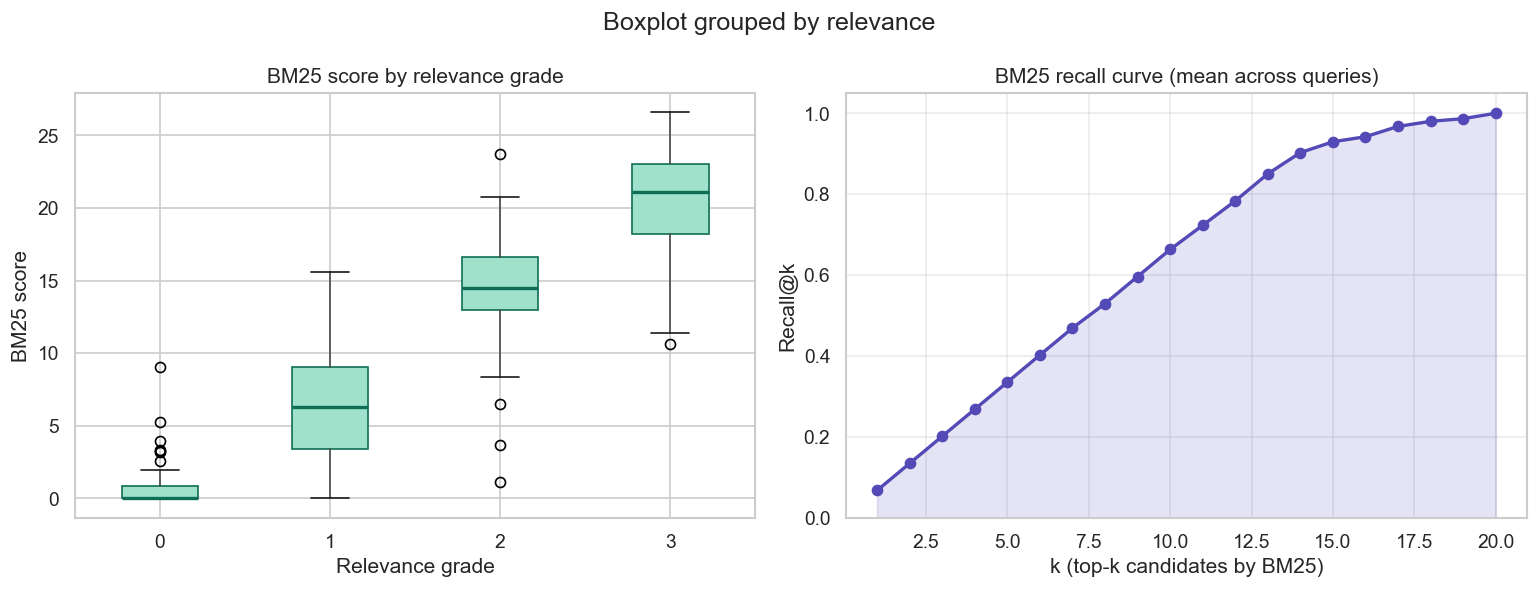

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Box plot: BM25 by relevance grade
df.boxplot(column='bm25_score', by=LABEL_COL, ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#9FE1CB', color='#0F6E56'),
           medianprops=dict(color='#0F6E56', linewidth=2))
axes[0].set_title('BM25 score by relevance grade')
axes[0].set_xlabel('Relevance grade')
axes[0].set_ylabel('BM25 score')
plt.sca(axes[0])
plt.title('BM25 score by relevance grade')

# Cumulative recall: how many relevant docs in top-k?
k_vals = list(range(1, 21))
recall_at_k_mean = []

for k in k_vals:
    recalls = []
    for qid, g in df.groupby(GROUP_COL):
        g_sorted = g.sort_values('bm25_score', ascending=False)
        n_rel = (g[LABEL_COL] >= 1).sum()
        if n_rel == 0:
            continue
        n_rel_in_topk = (g_sorted.head(k)[LABEL_COL] >= 1).sum()
        recalls.append(n_rel_in_topk / n_rel)
    recall_at_k_mean.append(np.mean(recalls))

axes[1].plot(k_vals, recall_at_k_mean, marker='o', color='#534AB7', linewidth=2)
axes[1].fill_between(k_vals, recall_at_k_mean, alpha=0.15, color='#534AB7')
axes[1].set_xlabel('k (top-k candidates by BM25)')
axes[1].set_ylabel('Recall@k')
axes[1].set_title('BM25 recall curve (mean across queries)')
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/eda_bm25_analysis.png', bbox_inches='tight')
plt.show()

## 8. Summary: key findings

In [10]:
top_feats = corr_df.head(3).index.tolist()
low_feats = corr_df[corr_df['spearman_r'].abs() < 0.05].index.tolist()

print('=== EDA Summary ===')
print(f'Dataset: {len(df):,} query-document pairs across {df[GROUP_COL].nunique()} queries')
print(f'Relevance: {(df[LABEL_COL]==0).mean()*100:.1f}% irrelevant, '
      f'{(df[LABEL_COL]>=1).mean()*100:.1f}% relevant')
print()
print(f'Top correlated features with relevance: {top_feats}')
if low_feats:
    print(f'Weak/no correlation (consider dropping): {low_feats}')
if high_corr:
    print(f'Collinear feature pairs to watch: {[(a, b) for a, b, _ in high_corr]}')
print()
print('Outputs saved to ../outputs/eda_*.png')

=== EDA Summary ===
Dataset: 200 query-document pairs across 10 queries
Relevance: 25.0% irrelevant, 75.0% relevant

Top correlated features with relevance: ['query_term_coverage', 'bm25_score', 'body_match_score']
Weak/no correlation (consider dropping): ['is_navigational', 'query_idf_sum']
Collinear feature pairs to watch: [('bm25_score', 'query_term_coverage'), ('bm25_score', 'body_match_score'), ('tfidf_cosine', 'query_term_coverage'), ('query_term_coverage', 'title_match_score'), ('query_term_coverage', 'body_match_score'), ('query_term_coverage', 'avg_click_rate'), ('body_match_score', 'avg_click_rate'), ('query_length', 'query_idf_sum')]

Outputs saved to ../outputs/eda_*.png
